# **Assignment 6- Perform Bagging and Boosting methods on IRIS dataset**

**Name -** Devanshee Gupta \
**Scholar No.-** 25P02F1001


### **1. Import necessary libraries**

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

### **2. Load the IRIS dataset**

In [ ]:
# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
print("Shape of X: ",X.shape)
print("Shape of Y: ",y.shape)

Shape of X:  (150, 4)
Shape of Y:  (150,)


### **3. Train / Test split (70:30 ratio)**

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **4. Perform Bagging methods (Random Forest Classifier)**

**RandomForestClassifier -**
It is a popular bagging algorithm that builds multiple decision trees on different bootstrap samples of the data and aggregates their predictions (by averaging for regression or majority voting for classification). \
**n_estimators -** controls the number of decision trees in the forest.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Initialize and train a Random Forest Classifier (a type of Bagging)
# n_estimators: number of trees in the forest
# random_state: for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

# Print the calculated metrics
print("\nBagging Model (RandomForestClassifier) Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision (weighted): {precision_rf:.4f}")
print(f"Recall (weighted): {recall_rf:.4f}")
print(f"F1-Score (weighted): {f1_rf:.4f}")


Bagging Model (RandomForestClassifier) Performance:
Accuracy: 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-Score (weighted): 1.0000


In [ ]:
# Generate a classification report
print("\nClassification Report for Bagging Model:\n")
print(classification_report(y_test, y_pred_rf))


Classification Report for Bagging Model:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



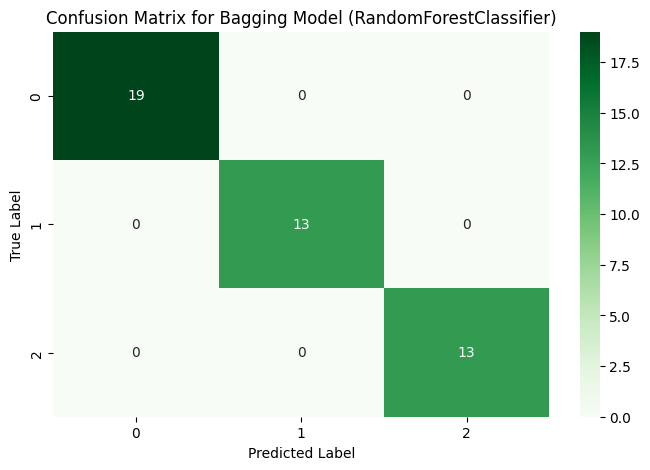

In [ ]:
# 6. Generate and visualize a confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix for Bagging Model (RandomForestClassifier)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### **5. Perform Boosting Methods (AdaBoost, GradientBoosting, XGBoost)**

Different Methods -

#### a. AdaBoost

* Method:
Adjusts the weights of misclassified data points, giving more importance to them in subsequent training rounds.
* Weak Learners:
Uses weak learners (e.g., decision stumps) and assigns them weights based on their accuracy.
* Pros:
Simple to implement and understand. Can be fast for simpler problems.
* Cons:
Sensitive to noisy data and outliers due to its focus on misclassified points.

#### b. Gradient Boosting

* Method:
Builds models sequentially, with each new model correcting the residual errors of the previous one using gradient descent on a loss function.
* Pros:
More flexible than AdaBoost, as it can handle various loss functions and is suitable for both regression and multi-class problems.
* Cons:
Can require more tuning and is slower than AdaBoost or XGBoost.

#### c. XGBoost
* Method:
An optimized version of Gradient Boosting that uses a more advanced optimization technique (like Newton-Raphson) to improve speed and accuracy.
* Key Features:
Includes built-in regularization (L1 and L2) to prevent overfitting.
Faster than vanilla Gradient Boosting due to optimizations like parallel processing and an approximate greedy algorithm.
Handles missing values inherently without needing imputation.
Supports multi-class classification natively.
* Pros:
State-of-the-art performance, faster speed, and more advanced features make it a popular choice for many applications.
* Cons:
More complex than AdaBoost.

### **6. Train & Evaluate the different models**

#### **a. AdaBoostClassifier (on IRIS Dataset) -**


In [ ]:
# import required libraries
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Initialize a base estimator (e.g., a shallow Decision Tree)
# max_depth: limits the depth of the tree, making it a "weak learner"
base_estimator = DecisionTreeClassifier(max_depth=1)

In [ ]:
# Initialize and train an AdaBoost Classifier
# n_estimators: number of boosting stages
# learning_rate: shrinks the contribution of each weak learner
ada_model = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, learning_rate=1.0, random_state=42)
ada_model.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   random_state=42)

In [ ]:
# Make predictions on the test set
y_pred_ada = ada_model.predict(X_test)

In [ ]:
# Evaluate the model
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost (Boosting) Accuracy: {accuracy_ada:.4f}")

AdaBoost (Boosting) Accuracy: 1.0000


In [ ]:
# Evaluate the model
accuracy_ada = accuracy_score(y_test, y_pred_ada)
precision_ada = precision_score(y_test, y_pred_ada, average='weighted')
recall_ada = recall_score(y_test, y_pred_ada, average='weighted')
f1_ada = f1_score(y_test, y_pred_ada, average='weighted')

# Print the calculated metrics
print("\nBoosting Model (AdaBoost) Performance:")
print(f"Accuracy: {accuracy_ada:.4f}")
print(f"Precision (weighted): {precision_ada:.4f}")
print(f"Recall (weighted): {recall_ada:.4f}")
print(f"F1-Score (weighted): {f1_ada:.4f}")


Boosting Model (AdaBoost) Performance:
Accuracy: 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-Score (weighted): 1.0000


In [ ]:
# Generate a classification report
print("\nClassification Report for boosting (AdaBoost) Model:\n")
print(classification_report(y_test, y_pred_ada))


Classification Report for boosting (AdaBoost) Model:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



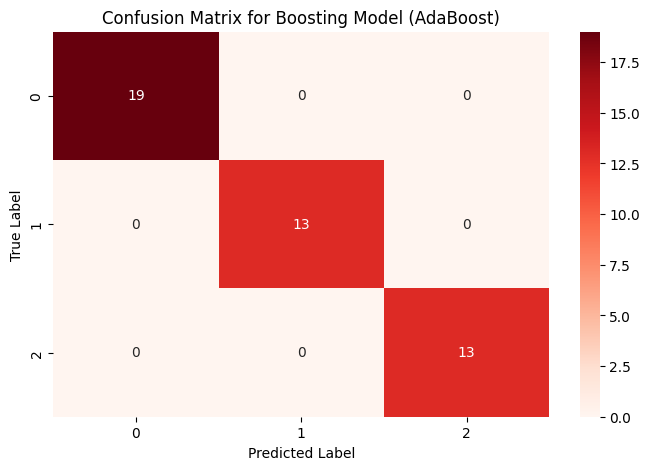

In [ ]:
# Generate and visualize a confusion matrix
cm_ada = confusion_matrix(y_test, y_pred_ada)

plt.figure(figsize=(8, 5))
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix for Boosting Model (AdaBoost)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### **b. GradientBoostingClassifier (on IRIS Dataset) -**

In [ ]:
# import required libraries
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# Initialize Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

In [ ]:
# Evaluate the model
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, average='weighted')
recall_gb = recall_score(y_test, y_pred_gb, average='weighted')
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')

# Print the calculated metrics
print("\nBoosting Model (GradientBoosting) Performance:")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision (weighted): {precision_gb:.4f}")
print(f"Recall (weighted): {recall_gb:.4f}")
print(f"F1-Score (weighted): {f1_gb:.4f}")


Boosting Model (GradientBoosting) Performance:
Accuracy: 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-Score (weighted): 1.0000


In [ ]:
# Generate a classification report
print("\nClassification Report for boosting (GradientBoosting) Model:\n")
print(classification_report(y_test, y_pred_gb))


Classification Report for boosting (GradientBoosting) Model:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



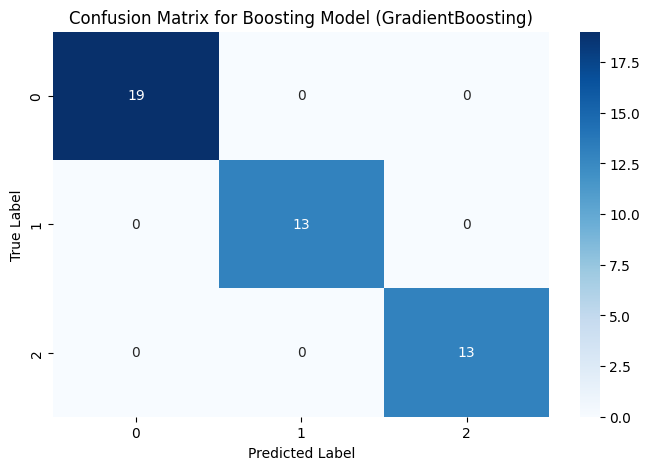

In [ ]:
# Generate and visualize a confusion matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(8, 5))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Boosting Model (GradientBoosting)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### **c. XGBoostClassifier (on IRIS Dataset) -**

In [ ]:
# import required libraries
from xgboost import XGBClassifier

In [ ]:
# 3. Define the model
# Common parameters include n_estimators (number of trees),
# learning_rate, and max_depth
xgb_model = XGBClassifier(
    objective='multi:softprob', # Objective for multi-class classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric='mlogloss' # Metric for multi-class logloss
)

In [ ]:
# Fit the model to the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

# Print the calculated metrics
print("\nBoosting Model (XGBoost) Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision (weighted): {precision_xgb:.4f}")
print(f"Recall (weighted): {recall_xgb:.4f}")
print(f"F1-Score (weighted): {f1_xgb:.4f}")


Boosting Model (XGBoost) Performance:
Accuracy: 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-Score (weighted): 1.0000


In [ ]:
# Generate a classification report
print("\nClassification Report for boosting (XGBoost) Model:\n")
print(classification_report(y_test, y_pred_xgb))


Classification Report for boosting (XGBoost) Model:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



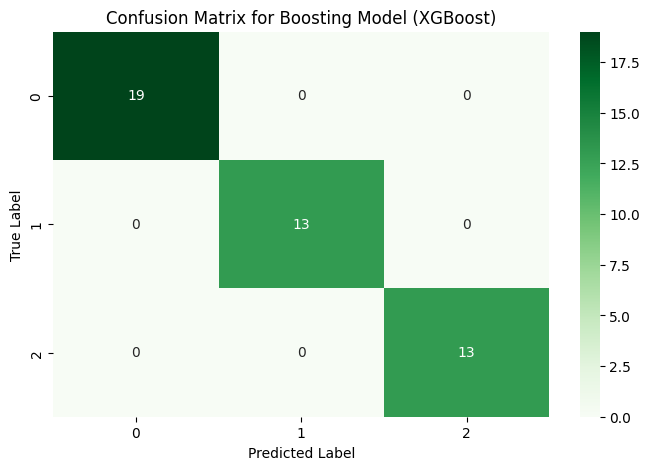

In [ ]:
# Generate and visualize a confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(8, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix for Boosting Model (XGBoost)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### **7. Assignment Summary**

This assignment involved applying and evaluating various Bagging (Random Forest) and Boosting (AdaBoost, Gradient Boosting, XGBoost) machine learning models on the Iris dataset. The primary goal was to demonstrate the implementation and performance metrics of these ensemble methods for classification tasks.



---